---
title: Ordinary differential equations in python
short_title: "Day 2, pt. 2: ODE"
---

# Ordinary differential equations in python

To solve ordinary differential equations, we will make use of the `integrate` subpackage of the `scipy` package

In [1]:
import scipy.integrate as sint

The main function we will use is the `solve_ivp()` function from this subpackage, [documented here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html).

Let's also import numpy and matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## The simplest case: first-order differential equation

`scipy.integrate` is capable of solving first-order differential equation of the form $\dot{y} = f(t, y)$, when an initial condition $y_0 = y(t_0)$ is given. As an explicit example, consider the logistic differential equation:
$$ \frac{dP}{dt} = r P \left( 1 - \frac{P}{K} \right)$$

In [3]:
# define the RHS of the differential equation

def f(t, P):
    return r * P * (1 - P / K)

r = 2
K = 100

In [4]:
# use solve_ivp() to solve the differential equation

t_span = [0, 10]
y0 = [20]
out = sint.solve_ivp(f, t_span, y0)

out

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  8.783e-02  8.117e-01  1.695e+00  2.322e+00
             2.949e+00  3.807e+00  4.835e+00  6.231e+00  8.135e+00
             1.000e+01]
        y: [[ 2.000e+01  2.296e+01  5.592e+01  8.814e+01  9.631e+01
              9.892e+01  9.979e+01  9.996e+01  9.999e+01  9.997e+01
              9.993e+01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 68
     njev: 0
      nlu: 0

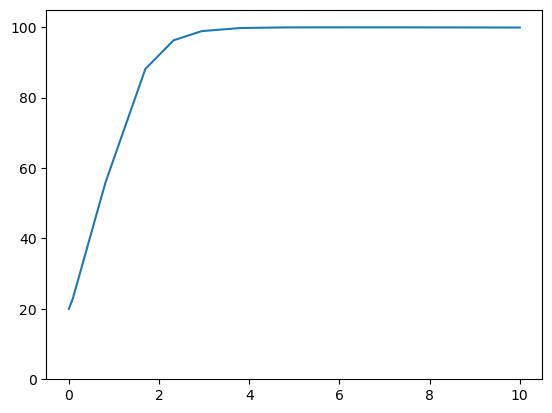

In [5]:
plt.plot(out.t, out.y[0])
plt.ylim(0, 105)
plt.show()

In [6]:
# specify evaluation points

t_array = np.linspace(0, 10, 100)

out2 = sint.solve_ivp(f, t_span, y0, t_eval=t_array)
out2

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.010e-01 ...  9.899e+00  1.000e+01]
        y: [[ 2.000e+01  2.343e+01 ...  9.992e+01  9.993e+01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 68
     njev: 0
      nlu: 0

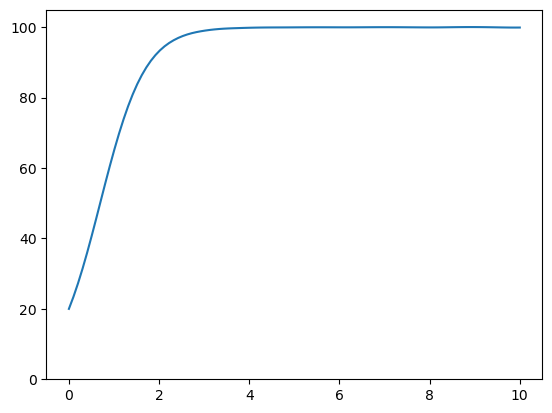

In [7]:
plt.plot(out2.t, out2.y[0])
plt.ylim(0, 105)
plt.show()

In [8]:
# request dense output

out3 = sint.solve_ivp(f, t_span, y0, dense_output=True)
out3

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  8.783e-02  8.117e-01  1.695e+00  2.322e+00
             2.949e+00  3.807e+00  4.835e+00  6.231e+00  8.135e+00
             1.000e+01]
        y: [[ 2.000e+01  2.296e+01  5.592e+01  8.814e+01  9.631e+01
              9.892e+01  9.979e+01  9.996e+01  9.999e+01  9.997e+01
              9.993e+01]]
      sol: <scipy.integrate._ivp.common.OdeSolution object at 0x000001A3E9125E50>
 t_events: None
 y_events: None
     nfev: 68
     njev: 0
      nlu: 0

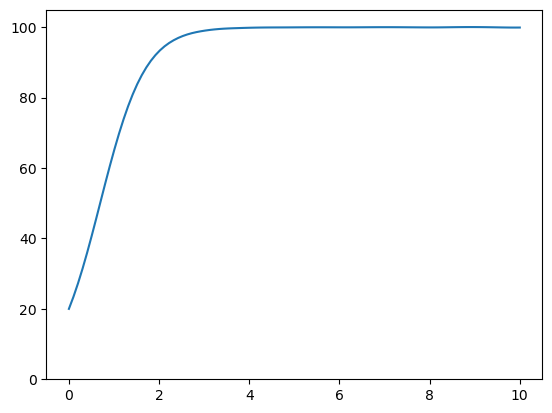

In [9]:
t_array = np.linspace(0, 10, 100)
P_array = out3.sol(t_array)[0]

plt.plot(t_array, P_array)
plt.ylim(0, 105)
plt.show()

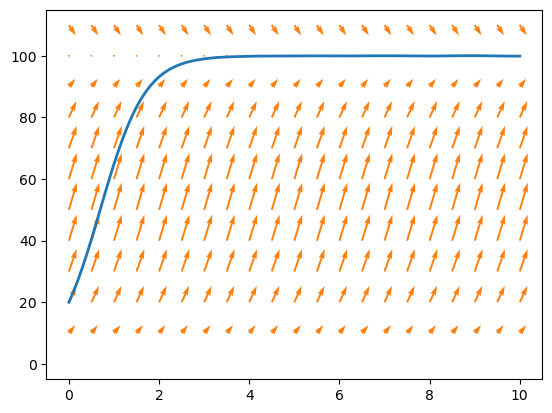

In [10]:
# add the quivers to illustrate the slope field

t_seq = np.arange(0, 10.1, 0.5)
y_seq = np.arange(10, 111, 10)
t_arr, y_arr = np.meshgrid(t_seq, y_seq)
t_arr = t_arr.flatten()
y_arr = y_arr.flatten()

u_arr = np.full_like(t_arr, 1.0)
v_arr = f(0, y_arr)

fig = plt.figure()
ax = fig.add_subplot()

ax.set_ylim([-5, 115])

ax.plot(out2.t, out2.y[0], lw=2)
ax.quiver(t_arr, y_arr, u_arr, v_arr, angles="xy", color="tab:orange")

plt.show(fig)

## System of first-order differential equations

`scipy.integrate` is also capable of solving a system of first-order differential equations. Conceptually, all we are doing is to promote $y$ (and hence $\dot{y}$) from a scalar to a 1D array. As before, we need to put the system of equations into the standard form $\dot{\mathbf{y}} = \mathbf{f}(t, \mathbf{y})$. When $\mathbf{y}$ is 2-dimensional, this expands to:
\begin{align}
    \dot{y}_1 & = f_1(t, y_1, y_2) \\
    \dot{y}_2 & = f_2(t, y_1, y_2)
\end{align}

As an explicit example, consider the Lotka-Volterra Predator-Prey Model. The system is (with $x$ being prey and $y$ being predator):
\begin{align}
    \frac{dx}{dt} & = \alpha x - \beta x y \\
    \frac{dy}{dt} & = -\gamma y + \delta x y
\end{align}


In [11]:
def predator_prey(t, Y):
    return [
        alpha * Y[0] - beta * Y[0] * Y[1],
        -gamma * Y[1] + delta * Y[0] * Y[1]
    ]

alpha = 24
beta = 0.4
gamma = 2.0
delta = 0.002

In [12]:
t_span = [0, 5]
Y0 = [3000, 50]

out = sint.solve_ivp(predator_prey, t_span, Y0, dense_output=True)

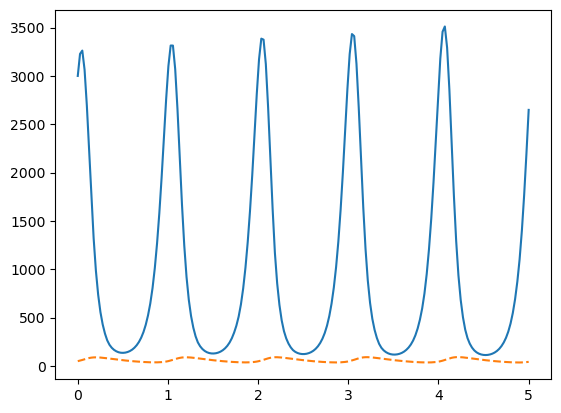

In [13]:
t_array = np.linspace(0, 5, 200)
Y_array = out.sol(t_array)

fig = plt.figure()
ax = fig.add_subplot()

ax.plot(t_array, Y_array[0], c="tab:blue", ls="-", label="prey")
ax.plot(t_array, Y_array[1], c="tab:orange", ls="--", label="predator")

plt.show(fig)

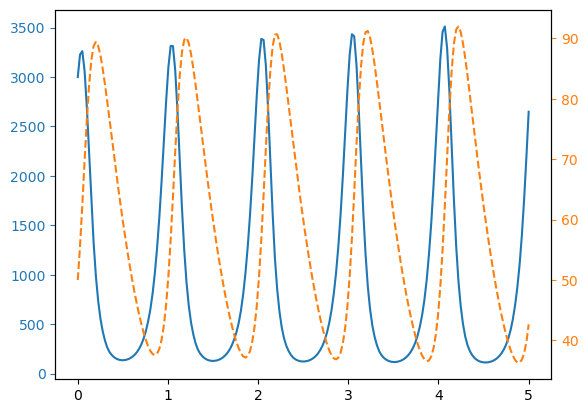

In [14]:
# using two vertical axes for clearer presentation

t_array = np.linspace(0, 5, 200)
Y_array = out.sol(t_array)

fig = plt.figure()
ax = fig.add_subplot()
ax2 = plt.twinx(ax)

ax.plot(t_array, Y_array[0], c="tab:blue", ls="-", label="prey")
ax.tick_params(axis='y', colors='tab:blue')

ax2.plot(t_array, Y_array[1], c="tab:orange", ls="--", label="predator")
ax2.tick_params(axis='y', colors='tab:orange')

plt.show(fig)

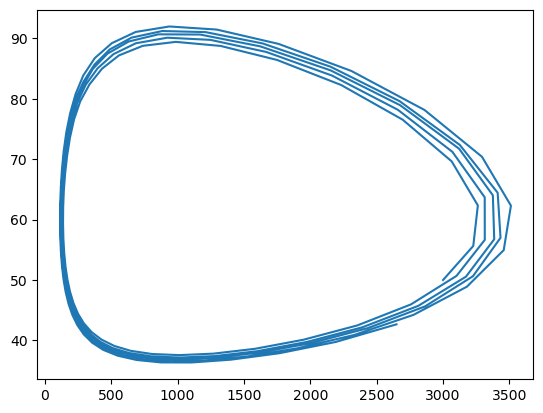

In [15]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(Y_array[0], Y_array[1], c="tab:blue", ls="-", label="prey")

plt.show(fig)

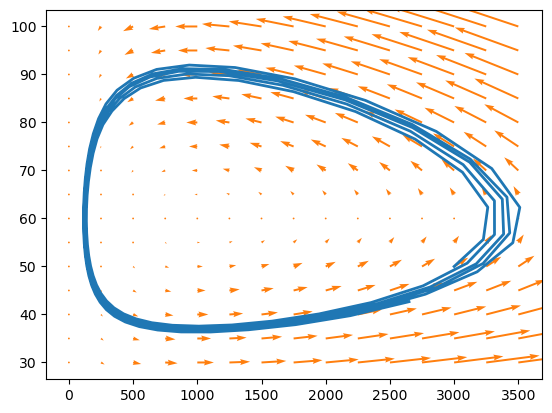

In [16]:
# add the quivers to illustrate the vector field

x_seq = np.arange(0, 3501, 250)
y_seq = np.arange(30, 101, 5)
x_arr, y_arr = np.meshgrid(x_seq, y_seq)
x_arr = x_arr.flatten()
y_arr = y_arr.flatten()

u_arr = np.array([])
v_arr = np.array([])

for x, y in zip(x_arr, y_arr):
    u, v = predator_prey(0, [x, y])
    u_arr = np.append(u_arr, u)
    v_arr = np.append(v_arr, v)

fig = plt.figure()
ax = fig.add_subplot()

ax.plot(Y_array[0], Y_array[1], lw=2)
ax.quiver(x_arr, y_arr, u_arr, v_arr, angles="xy", color="tab:orange")

plt.show(fig)

In [17]:
# switch to an implicit solver
out2 = sint.solve_ivp(predator_prey, t_span, Y0, method="Radau", dense_output=True)

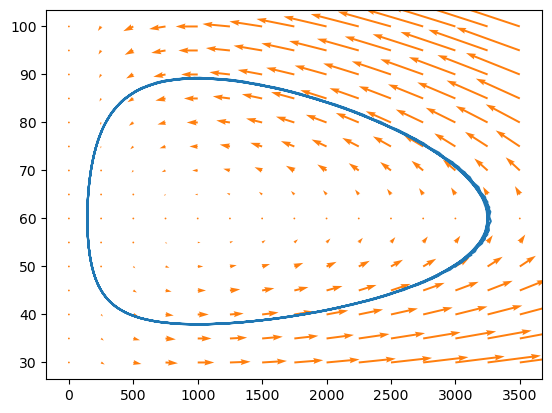

In [18]:
t_array = np.linspace(0, 5, 200)
Z_array = out2.sol(t_array)

fig = plt.figure()
ax = fig.add_subplot()

ax.plot(Z_array[0], Z_array[1], c="tab:blue", ls="-", label="prey")
ax.quiver(x_arr, y_arr, u_arr, v_arr, angles="xy", color="tab:orange")

plt.show(fig)

## Cumulative exercise: van der Pol oscillator

The van der Pol oscillator has been used to model cardiac activities. It is a second-order ODE of the form:

$$  \frac{d^{2}x}{dt^{2}} - \mu (1-x^{2}) \frac{dx}{dt} + x = 0 $$

For our purpose set $\mu = 1.5$. Solve the ODE for a variety of initial condition $\left(x(0), \dot{x}(0)\right)$, and plot their phase-space trajectories $(x(t), \dot{x}(t))$ on the same figure

**Hint**: `scipy.integrate` does not directly come with a higher-order ODE solver. However, there is a standard trick that convert a higher-order ODE into a system of first-order ODE. At second order the trick amounts to setting $y = \dot{x}$, which in itself becomes one of the equations of the system, while the original differential equation becomes an equation of the form $\dot{y} = f(x, y, t)$.